In [ ]:
%cd ..

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import transforms
from project.models import EDMMauMau, EDMLuomen
from project.util.device import get_available_acc
from project.util.transforms import Difference
from project.util.data import ReplayMemoryData

In [92]:
PATH = os.path.join("checkpoints", "diff", "Fern", "Difference", "Breakout.pt")
DATA = os.path.join("checkpoints", "memory", "Breakout.pt")
SIGMA = 0.5

In [ ]:
device = get_available_acc()
device

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    Difference(),
    transforms.Normalize(0.5, 0.5),
    transforms.Pad(2),
])

In [ ]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=1_000_000
)

In [89]:
model = EDMLuomen.from_checkpoint(PATH, device, sigma_noise=SIGMA, N=8).to(device)
model_naive = EDMMauMau.from_checkpoint(PATH, device, sigma_noise=SIGMA).to(device)

In [90]:
x = torch.zeros((4, 7, 88, 88), device=device)

for i, img in enumerate(torch.randperm(1000000)[:4]):
    x[i] = data[img].to(device)

x_noisy = x + SIGMA * torch.randn_like(x)
x_denoised = model.denoise(x)
x_naive_denoised = model_naive.denoise(x)

100%|██████████| 3/3 [00:00<00:00,  5.33it/s]


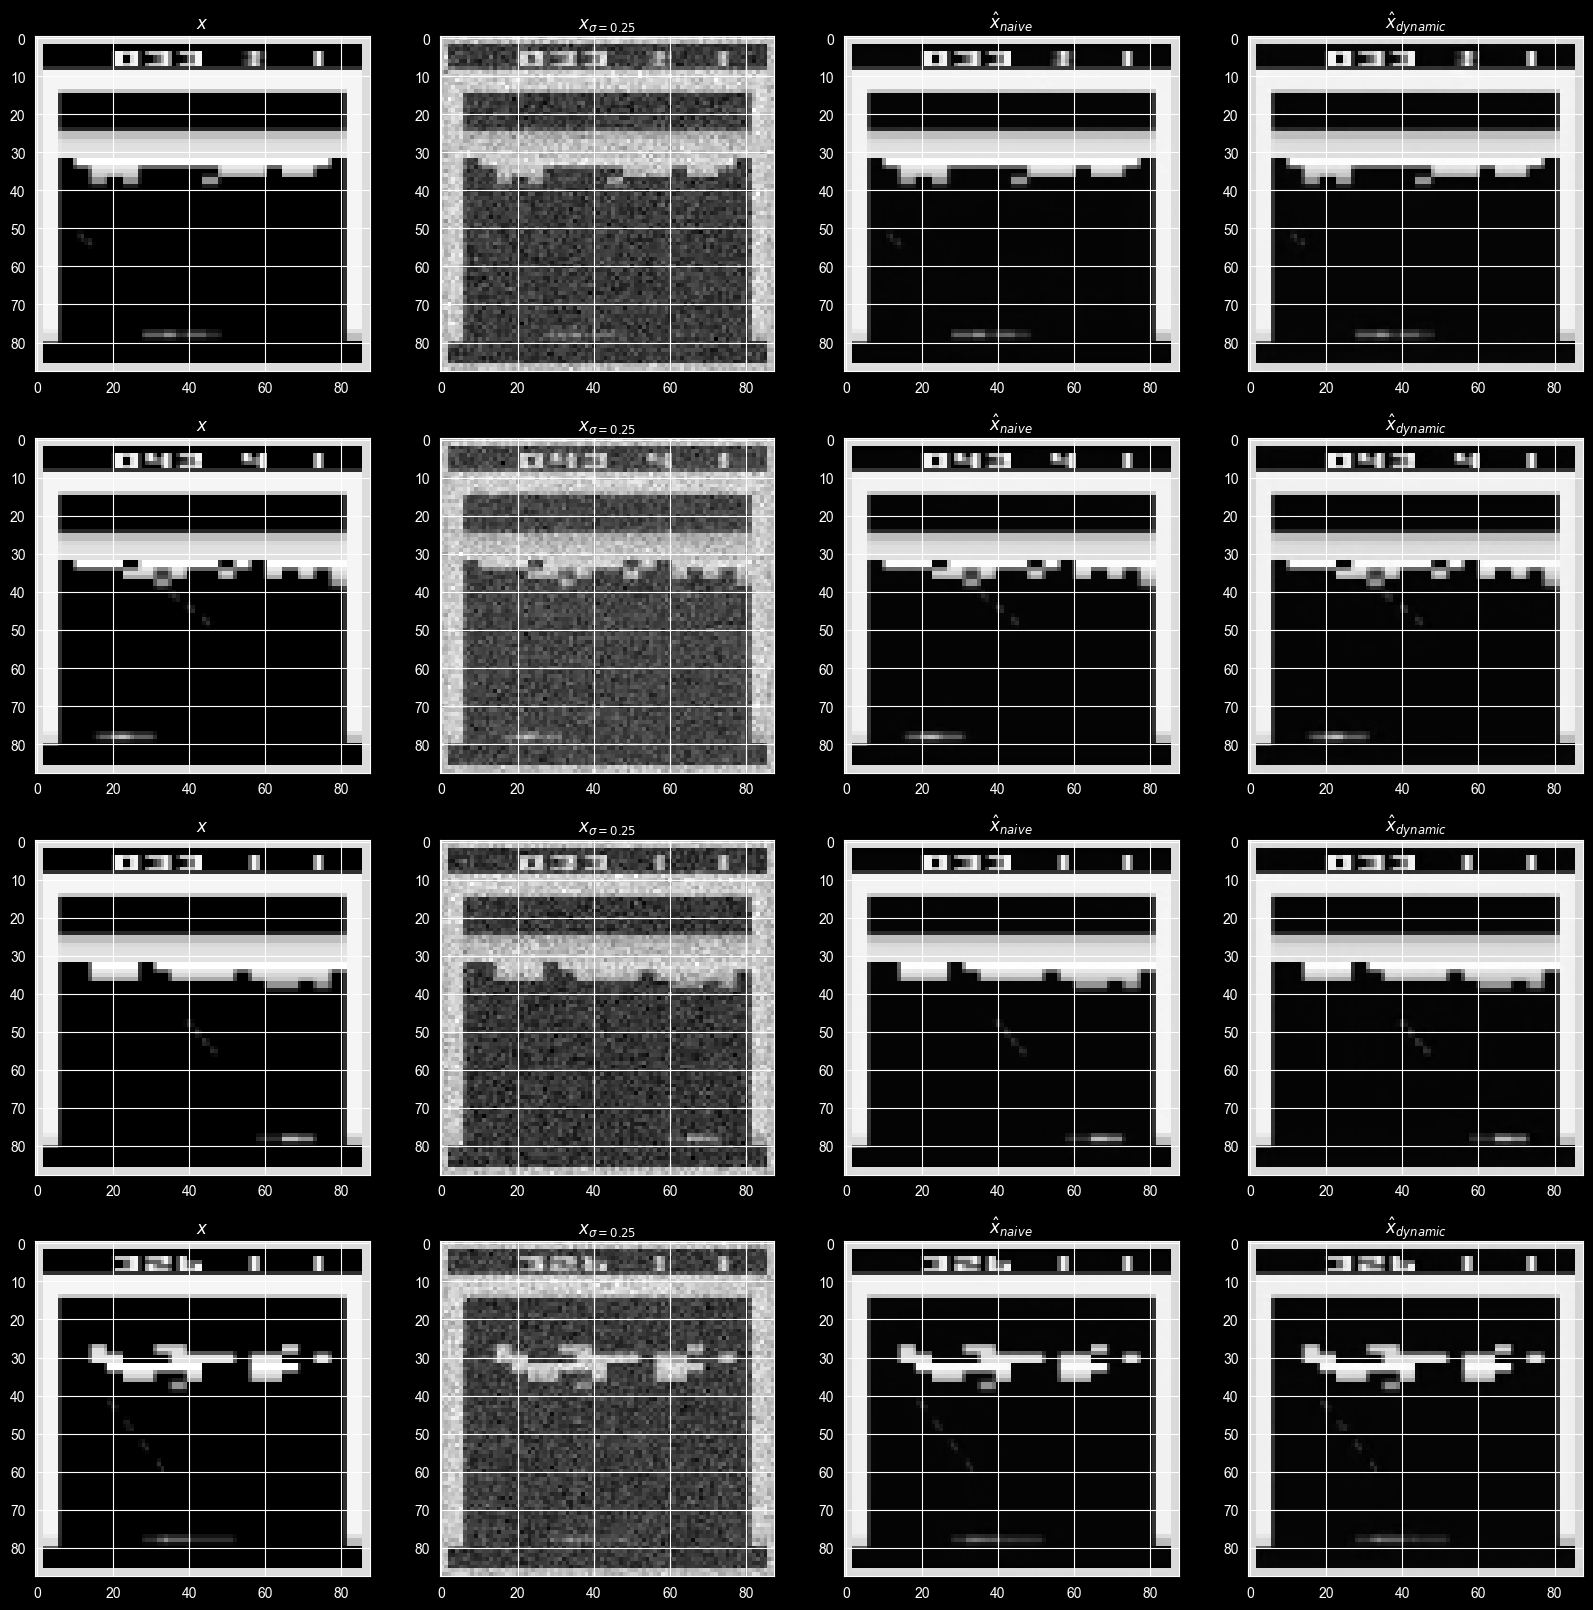

In [91]:
fig, axis = plt.subplots(4, 4, figsize=(20, 20))

for i in range(4):
    axis[i, 0].imshow(x[i, :4].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 1].imshow(x_noisy[i, :4].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 2].imshow(x_naive_denoised[i, :4].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 3].imshow(x_denoised[i, :4].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 0].set_title("$x$")
    axis[i, 1].set_title("$x_{\\sigma = " + f"{SIGMA}" + "}$")
    axis[i, 2].set_title("$\\hat{x}_{naive}$")
    axis[i, 3].set_title("$\\hat{x}_{dynamic}$")

plt.savefig(os.path.join("data", "evaluation", "denoise", f"sigma_{SIGMA}.png"))
plt.show()